# Trajectory comparison between 1PAT1R and KerrEccEq

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
from scipy.interpolate import CubicSpline

In [3]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 0.0       # primary spin chi1 (dimensionless)
p0 = 9.5      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.0           # secondary spin

dt = 5.   # time step [s]
T  = 4    # total duration [yr]

In [4]:
traj1PA = EMRIInspiral(func=Trajectory1PAT1R)
traj0PA = EMRIInspiral(func=KerrEccEqFlux)

traj_key = ['t', 'p', 'e', 'xI', 'Phi_phi', 'Phi_theta', 'Phi_r', 'dM', 'dchi1']

traj_1PA = traj1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,     # extra arg -> additional_args[0]
    T=T
)

traj_0PA_tmp = traj0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
)

traj_0PA = np.zeros_like(traj_1PA)
for i in range(len(traj_0PA_tmp)):
    cspl = CubicSpline(traj_0PA_tmp[0], traj_0PA_tmp[i])
    traj_0PA[i] = cspl(traj_1PA[0])

traj_0PA_dic = {key: traj_0PA[i] for i, key in enumerate(traj_key)}
traj_1PA_dic = {key: traj_1PA[i] for i, key in enumerate(traj_key)}

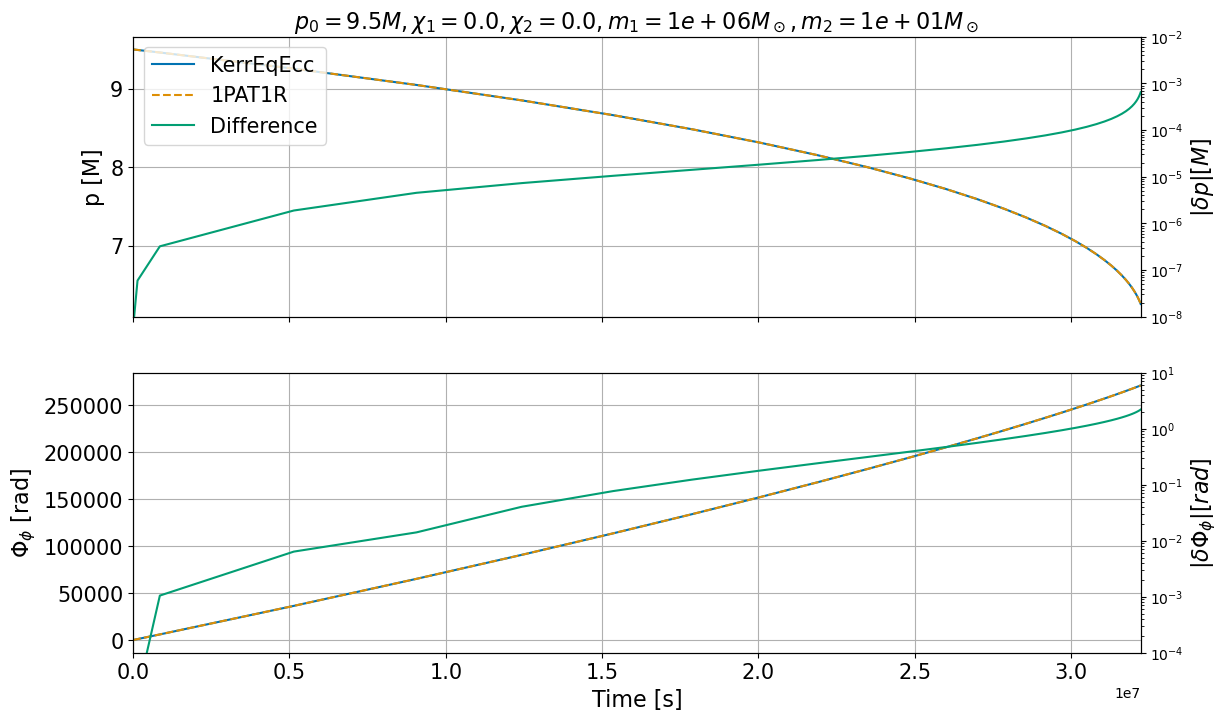

In [6]:
import seaborn as sns
colorblind_palette = sns.color_palette('colorblind')
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

colorblind_hex = [mcolors.to_hex(color) for color in colorblind_palette]

#plt.rcParams["text.usetex"] = True
#plt.rcParams["font.family"] = "serif"
#plt.rcParams["font.serif"] = ["Computer Modern"]


fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fontsize = 16

axes[0].set_title(rf"$p_0={p0}M, \chi_1={a}, \chi_2={chi2}, m_1 ={m1:.0e}M_\odot, m_2={m2:.0e}M_\odot$", fontsize=fontsize)

axes[0].plot(traj_0PA_dic['t'], traj_0PA_dic['p'], label='KerrEqEcc', color=colorblind_hex[0])
axes[0].plot(traj_1PA_dic['t'], traj_1PA_dic['p'], linestyle="--", label='1PAT1R', color=colorblind_hex[1])
axes[0].set_ylabel("p [M]", fontsize=fontsize)
axes[0].plot([],label='Difference',c=colorblind_hex[2])
axes[0].set_xlim([0, traj_0PA_dic['t'].max()])
axes[0].grid()
axes[0].legend(fontsize=fontsize-1, loc="upper left")
axes[0].tick_params(labelsize=fontsize-1)

ax02 = axes[0].twinx()

ax02.set_ylabel(rf'$|\delta p| [M]$', fontsize=fontsize)
ax02.plot(traj_0PA_dic['t'], np.abs(traj_0PA_dic['p'] - traj_1PA_dic['p']), label='relative difference', c=colorblind_hex[2])
ax02.tick_params(axis='y')
plt.yscale("log")
plt.ylim([1e-8, 1e-2])



axes[1].plot(traj_0PA_dic['t'], traj_0PA_dic['Phi_phi'], label='KerrEqEccFlux', color=colorblind_hex[0])
axes[1].plot(traj_1PA_dic['t'], traj_1PA_dic['Phi_phi'], linestyle="--", label='1PAT1R', color=colorblind_hex[1])
axes[1].set_ylabel(r"$\Phi_\phi$ [rad]", fontsize=fontsize)
axes[1].plot([],label='Difference',c=colorblind_hex[2])
axes[1].set_xlim([0, traj_0PA_dic['t'].max()])
axes[1].grid()
axes[1].tick_params(labelsize=fontsize-1)

ax12 = axes[1].twinx()

ax12.set_ylabel(rf'$|\delta\Phi_\phi| [rad]$', fontsize=fontsize)
ax12.plot(traj_0PA_dic['t'], np.abs(traj_0PA_dic['Phi_phi'] - traj_1PA_dic['Phi_phi']), label='relative difference', c=colorblind_hex[2])
ax12.tick_params(axis='y')
plt.yscale("log")
plt.ylim([1e-4, 1e1])

axes[1].set_xlabel("Time [s]", fontsize=fontsize)
plt.show()


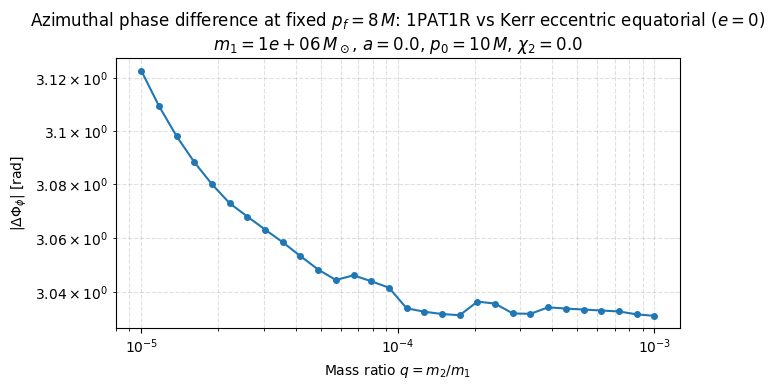

In [16]:
# --- Phase difference vs mass ratio ---
# Compare the azimuthal phase accumulated between Trajectory1PAT1R (1PA)
# and KerrEccEqFlux (0PA) at a fixed final semi-latus rectum p_final.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# --- Parameters ---
m1      = 1e6
a       = 0.0
p0      = 10
p_final = 8
chi2    = 0.0
Tmax    = 10.0   # long enough to reach p_final

traj1PA  = EMRIInspiral(func=Trajectory1PAT1R)
traj0PA  = EMRIInspiral(func=KerrEccEqFlux)

q_values = np.logspace(-5, -3, 30)
m2_values = q_values * m1

delta_Phi_phi = np.zeros(len(q_values))
delta_Phi_phi[:] = np.nan   # mark failures

for i, (q, m2) in enumerate(zip(q_values, m2_values)):

    # Integrate both inspirals
    t1, p1_, e1_, xI1_, Phi_phi_1PA, *_ = traj1PA(
        m1, m2, a, p0, 0.0, 1.0, chi2, T=Tmax
    )
    t0, p0_, e0_, xI0_, Phi_phi_0PA, *_ = traj0PA(
        m1, m2, a, p0, 0.0, 1.0, T=Tmax
    )

    # Check if p_final is reached
    if not ((p1_[0] - p_final) * (p1_[-1] - p_final) < 0):
        print(f"1PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    if not ((p0_[0] - p_final) * (p0_[-1] - p_final) < 0):
        print(f"0PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    # Build splines
    cs_p1   = CubicSpline(t1, p1_)
    cs_phi1 = CubicSpline(t1, Phi_phi_1PA)

    cs_p0   = CubicSpline(t0, p0_)
    cs_phi0 = CubicSpline(t0, Phi_phi_0PA)

    # Solve p(t) = p_final
    t1_f = brentq(lambda tt: cs_p1(tt) - p_final, t1[0], t1[-1])
    t0_f = brentq(lambda tt: cs_p0(tt) - p_final, t0[0], t0[-1])

    # Evaluate phases
    Phi1_f = cs_phi1(t1_f)
    Phi0_f = cs_phi0(t0_f)

    delta_Phi_phi[i] = abs(Phi1_f - Phi0_f)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q_values, delta_Phi_phi, marker='o', ms=4, lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Mass ratio $q = m_2 / m_1$')
ax.set_ylabel(r'$|\Delta\Phi_\phi|$ [rad]')
ax.set_title(
    rf'Azimuthal phase difference at fixed $p_f={p_final}\,M$: '
    '1PAT1R vs Kerr eccentric equatorial ($e=0$)'
    '\n'
    rf'$m_1={m1:.0e}\,M_\odot$, $a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$'
)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()


Clearly a 1PA phase error.

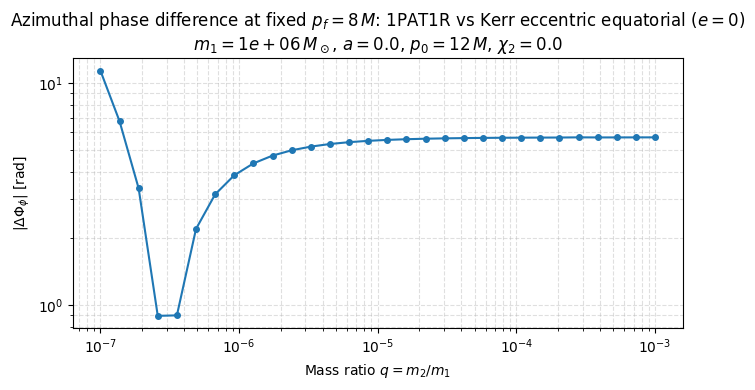

In [17]:
# --- Phase difference vs mass ratio ---
# Compare the azimuthal phase accumulated between Trajectory1PAT1R (1PA)
# and KerrEccEqFlux (0PA) at a fixed final semi-latus rectum p_final.

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq

# --- Parameters ---
m1      = 1e6
a       = 0.0
p0      = 12
p_final = 8
chi2    = 0.0
Tmax    = 400.0   # long enough to reach p_final

traj1PA  = EMRIInspiral(func=Trajectory1PAT1R)
traj0PA  = EMRIInspiral(func=KerrEccEqFlux)

q_values = np.logspace(-7, -3, 30)
m2_values = q_values * m1

delta_Phi_phi = np.zeros(len(q_values))
delta_Phi_phi[:] = np.nan   # mark failures

for i, (q, m2) in enumerate(zip(q_values, m2_values)):

    # Integrate both inspirals
    t1, p1_, e1_, xI1_, Phi_phi_1PA, *_ = traj1PA(
        m1, m2, a, p0, 0.0, 1.0, chi2, T=Tmax
    )
    t0, p0_, e0_, xI0_, Phi_phi_0PA, *_ = traj0PA(
        m1, m2, a, p0, 0.0, 1.0, T=Tmax
    )

    # Check if p_final is reached
    if not ((p1_[0] - p_final) * (p1_[-1] - p_final) < 0):
        print(f"1PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    if not ((p0_[0] - p_final) * (p0_[-1] - p_final) < 0):
        print(f"0PA: q={q:.2e} did not reach p_final={p_final}")
        continue

    # Build splines
    cs_p1   = CubicSpline(t1, p1_)
    cs_phi1 = CubicSpline(t1, Phi_phi_1PA)

    cs_p0   = CubicSpline(t0, p0_)
    cs_phi0 = CubicSpline(t0, Phi_phi_0PA)

    # Solve p(t) = p_final
    t1_f = brentq(lambda tt: cs_p1(tt) - p_final, t1[0], t1[-1])
    t0_f = brentq(lambda tt: cs_p0(tt) - p_final, t0[0], t0[-1])

    # Evaluate phases
    Phi1_f = cs_phi1(t1_f)
    Phi0_f = cs_phi0(t0_f)

    delta_Phi_phi[i] = abs(Phi1_f - Phi0_f)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q_values, delta_Phi_phi, marker='o', ms=4, lw=1.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Mass ratio $q = m_2 / m_1$')
ax.set_ylabel(r'$|\Delta\Phi_\phi|$ [rad]')
ax.set_title(
    rf'Azimuthal phase difference at fixed $p_f={p_final}\,M$: '
    '1PAT1R vs Kerr eccentric equatorial ($e=0$)'
    '\n'
    rf'$m_1={m1:.0e}\,M_\odot$, $a={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$'
)
ax.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()
